# Kitaev Chain: p-wave BdG Hamiltonian as an MPO

Builds the **Kitaev chain** — the canonical 1D p-wave topological superconductor — using the TensorBinding high-level API:

1. `get_Hamiltonian("chain_1d", -t; L=L)` — OBC nearest-neighbour kinetic MPO.
2. `add_onsite!(H, _ -> -μ)` — uniform chemical potential.
3. `add_superconductivity!(H, Δ_pair; type=:custom)` — BdG extension:
   $$H_\mathrm{BdG} = \tau_z\otimes H_\mathrm{kin} \;+\; \tau_+\otimes H_\mathrm{pair} \;+\; \tau_-\otimes H_\mathrm{pair}^\dagger$$

**BdG spectrum** (thermodynamic limit):
$$E(k) = \pm\sqrt{\xi(k)^2 + \Delta^2}, \qquad \xi(k) = -2t\cos k - \mu$$

The topological phase transition occurs at $|\mu| = 2t$.

**Site layout** after `add_superconductivity!` (`:pre` convention):
$$\underbrace{b_0}_{\text{Nambu}} \;\underbrace{b_1 \cdots b_L}_{\text{position}} \qquad \text{state 1 = particle,  state 2 = hole}$$

In [33]:
using LinearAlgebra
using Plots
using ITensors
using ITensorMPS
include("../src/TensorBinding.jl")
using .TensorBinding

---
## Build the Hamiltonian

In [34]:
L = 5       # position qubits → N = 2^L = 256 sites
N = 2^L
t = 1.0     # NN hopping amplitude
Δ = 0.5     # p-wave pairing amplitude
μ = -1.0    # chemical potential  (topological phase: |μ| < 2t)

H = TensorBinding.get_Hamiltonian("chain_1d", -t; L=L)   # H = -t(A + A†), OBC
TensorBinding.add_onsite!(H, _ -> -μ)                     # → H_kin = -t(A+A†) - μI

# p-wave pairing: H_pair[i+1, i] = Δ 
Δ_pair(i, j) = i == j + 1 ? ComplexF64(Δ) : 0.001
TensorBinding.add_superconductivity!(H, Δ_pair; type=:custom, position=:pre)

println(H)

MPS COMPUTED!
Turned into MPO!
TBHamiltonian | L=5, N=32 +BdG, scale=auto, maxlinkdim=6 | geometry: 32 sites, 1D | no Tn cache


---
## Validation: small system exact diagonalisation ($L=2$, $N=4$)

For $N=4$ sites the BdG Hilbert space has $2N=8$ states.
`get_matrix` extracts the full dense matrix; eigenvalues are compared to the
explicit OBC BdG reference:

$$H_\mathrm{BdG}^\mathrm{exact} = \begin{pmatrix} H_\mathrm{kin} & \Delta A \\ \Delta A^\dagger & -H_\mathrm{kin} \end{pmatrix}$$

where $H_\mathrm{kin}$ is the $4\times4$ OBC tridiagonal and $A$ is the OBC forward-shift matrix.

In [28]:
L_s = 2;  N_s = 2^L_s

H_s = TensorBinding.get_Hamiltonian("chain_1d", -t; L=L_s)
TensorBinding.add_onsite!(H_s, _ -> -μ)
TensorBinding.add_superconductivity!(H_s, (i, j) -> i == j + 1 ? ComplexF64(Δ) : 0.0; type=:custom)

M         = real.(TensorBinding.get_matrix(H_s.mpo, H_s.sites))
eigenvals = sort(real.(eigvals(M)))

# Reference: explicit OBC BdG matrix
H_kin_ref = diagm(0 => fill(-μ, N_s), 1 => fill(-t, N_s-1), -1 => fill(-t, N_s-1))
A_ref     = diagm(-1 => ones(N_s - 1))        # A_ref[i+1,i] = 1, OBC
H_BdG_ref = [H_kin_ref  Δ*A_ref; Δ*A_ref'  -H_kin_ref]
E_ref     = sort(real.(eigvals(H_BdG_ref)))

println("MPO eigenvalues:       ", round.(eigenvals; digits=6))
println("Reference eigenvalues: ", round.(E_ref;     digits=6))
println("Max error            : ", maximum(abs.(eigenvals .- E_ref)))
println("Hermiticity  ‖H-H†‖  : ", norm(M - M'))

MPS COMPUTED!
Turned into MPO!
MPO eigenvalues:       [-2.661772, -1.679767, -0.845906, -0.357488, 0.357488, 0.845906, 1.679767, 2.661772]
Reference eigenvalues: [-2.661772, -1.679767, -0.845906, -0.357488, 0.357488, 0.845906, 1.679767, 2.661772]
Max error            : 1.5543122344752192e-15
Hermiticity  ‖H-H†‖  : 3.663090703109676e-15


---
## KPM density of states  ($N = 256$ per sector)

`KPM_Tn(H, Ncheb)` builds the Chebyshev polynomial list on the full BdG site
space and caches it in `H`.  Spectral bounds are estimated automatically via DMRG.
The BdG DoS is particle-hole symmetric and shows the quasiparticle gap $2|\Delta|$.
The Tn cache is reused by the band-structure cell below — no extra computation needed.

Computing DoS at ω = -3.297
Computing DoS at ω = -3.23
Computing DoS at ω = -3.164
Computing DoS at ω = -3.097
Computing DoS at ω = -3.03
Computing DoS at ω = -2.964
Computing DoS at ω = -2.897
Computing DoS at ω = -2.831
Computing DoS at ω = -2.764
Computing DoS at ω = -2.697
Computing DoS at ω = -2.631
Computing DoS at ω = -2.564
Computing DoS at ω = -2.498
Computing DoS at ω = -2.431
Computing DoS at ω = -2.364
Computing DoS at ω = -2.298
Computing DoS at ω = -2.231
Computing DoS at ω = -2.165
Computing DoS at ω = -2.098
Computing DoS at ω = -2.031
Computing DoS at ω = -1.965
Computing DoS at ω = -1.898
Computing DoS at ω = -1.832
Computing DoS at ω = -1.765
Computing DoS at ω = -1.698
Computing DoS at ω = -1.632
Computing DoS at ω = -1.565
Computing DoS at ω = -1.499
Computing DoS at ω = -1.432
Computing DoS at ω = -1.365
Computing DoS at ω = -1.299
Computing DoS at ω = -1.232
Computing DoS at ω = -1.166
Computing DoS at ω = -1.099
Computing DoS at ω = -1.032
Computing DoS at ω = -

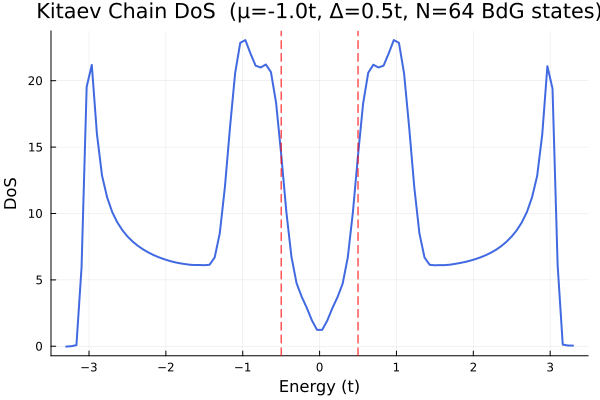

In [37]:
Ncheb  = 80
maxdim = 100

# site_idx  = H.N ÷ 2
# psi_site  = TensorBinding._basis_state_mps(site_idx, H.sites)
# ldos_1d   = Float64[]
# TensorBinding.KPM_Tn(H, Ncheb; mode=:mps, psi0=psi_site, maxdim=maxdim, cutoff=1e-6)
TensorBinding.KPM_Tn(H, Ncheb; maxdim=maxdim, cutoff=1e-6)


ω_phys = range(-H.scale * 0.99, H.scale * 0.99; length=100)
dos = [begin
    println("Computing DoS at ω = ", round(ω, digits=3))
    ω_r = (ω - H.center) / H.scale
    abs(ω_r) >= 1.0 ? 0.0 :
        real(tr(TensorBinding.get_ldos_w_from_Tn(H._tn_cache, H._tn_Ncheb, ω_r; maxdim=maxdim)))
end for ω in ω_phys]

# dos      = [TensorBinding.get_ldos(H, ω_p; mode=:mps, psi0=psi_site,
#                      kernel=:jackson, eta=1/(Ncheb-1)) for ω_p in ω_phys]

plot(ω_phys, dos;
     xlabel="Energy (t)", ylabel="DoS",
     title="Kitaev Chain DoS  (μ=$(μ)t, Δ=$(Δ)t, N=$(2N) BdG states)",
     legend=false, lw=2, color=:royalblue)
vline!([-Δ, Δ]; ls=:dash, color=:red, label="±Δ")

In [38]:
H.sites

6-element Vector{Index{Int64}}:
 (dim=2|id=482|"Nambu")
 (dim=2|id=301|"Qubit,Site,n=1")
 (dim=2|id=443|"Qubit,Site,n=2")
 (dim=2|id=245|"Qubit,Site,n=3")
 (dim=2|id=797|"Qubit,Site,n=4")
 (dim=2|id=136|"Qubit,Site,n=5")

---
## Phase diagram: DoS heatmap vs $\mu$

Sweep $\mu$ from $-4t$ to $+4t$.  The spectral scale is set analytically for
each $\mu$ — $E_\mathrm{max} = \sqrt{(2t+|\mu|)^2+\Delta^2}$ — to skip the DMRG
estimation inside the loop.  The topological transition at $|\mu|=2t$ is visible
as a narrowing of the gap region in the heatmap.

In [ ]:
μ_sweep     = range(-4.0, 4.0; length=17)
ω_sweep     = range(-4.5, 4.5; length=200)
dos_sweep   = Matrix{Float64}(undef, length(ω_sweep), length(μ_sweep))
Ncheb_scan  = 60
maxdim_scan = 80

for (iμ, μ_loc) in enumerate(μ_sweep)
    H_loc = get_Hamiltonian("chain_1d", -t; L=L)
    add_onsite!(H_loc, _ -> -μ_loc)
    add_superconductivity!(H_loc, Δ_pair; type=:custom)
    # Analytic scale estimate — avoids DMRG on every μ step
    H_loc.scale  = sqrt((2t + abs(μ_loc))^2 + Δ^2) * 1.1
    H_loc.center = 0.0
    KPM_Tn(H_loc, Ncheb_scan; maxdim=maxdim_scan)

    for (iω, ω) in enumerate(ω_sweep)
        ω_r = ω / H_loc.scale
        dos_sweep[iω, iμ] = abs(ω_r) >= 1.0 ? 0.0 :
            real(tr(get_ldos_w_from_Tn(H_loc._tn_cache, Ncheb_scan, ω_r; maxdim=maxdim_scan)))
    end
    println("μ = $(round(μ_loc; digits=1)) done")
end

heatmap(collect(μ_sweep), collect(ω_sweep), dos_sweep;
        xlabel="Chemical potential μ (t)", ylabel="Energy (t)",
        title="Kitaev Chain DoS vs μ  (Δ=$(Δ)t, N=$(2N) BdG states)",
        color=:inferno, colorbar_title="DoS")
vline!([-2t, 2t]; ls=:dash, color=:cyan, lw=2, label="μ = ±2t")

---
## Nambu band structure: $A(k, \omega)$

`get_bands` conjugates the KPM spectral MPO with the QFT acting on position
qubits, with identity operators padding the Nambu site.  The Tn cache from
the DoS cell is reused — no extra `KPM_Tn` call needed.

Three views, controlled by `aux_proj`:
| Call | Result |
|---|---|
| `get_bands(H, ω)` | **Trace** — $A(k,\omega)=\sum_\sigma\langle\sigma,k\|\tilde{A}\|\sigma,k\rangle$ |
| `get_bands(H, ω; aux_proj=[1])` | **Electrons** — particle sector ($\sigma=1$) |
| `get_bands(H, ω; aux_proj=[2])` | **Holes** — hole sector ($\sigma=2$) |

The $k$-axis follows the quantics QFT mode ordering (bit-reversed relative to
the physical Brillouin zone, but the two dispersive branches $E_\pm(k)$ are clearly visible).

In [ ]:
ω_bands      = range(-H.scale * 0.99, H.scale * 0.99; length=80)
maxdim_bands = 100

Ak_trace = TensorBinding.get_bands(H, ω_bands; maxdim=maxdim_bands)               # sum over Nambu
Ak_elec  = TensorBinding.get_bands(H, ω_bands; aux_proj=[1], maxdim=maxdim_bands) # particle sector
Ak_hole  = TensorBinding.get_bands(H, ω_bands; aux_proj=[2], maxdim=maxdim_bands) # hole sector

clim = (0, maximum(Ak_trace))
ks   = 0:N-1

p1 = heatmap(ks, collect(ω_bands), Ak_trace;
             title="Trace (both sectors)", xlabel="QFT mode k", ylabel="E (t)",
             color=:inferno, clims=clim, colorbar=false)
p2 = heatmap(ks, collect(ω_bands), Ak_elec;
             title="Electrons (state 1)", xlabel="QFT mode k",
             color=:inferno, clims=clim, colorbar=false)
p3 = heatmap(ks, collect(ω_bands), Ak_hole;
             title="Holes (state 2)", xlabel="QFT mode k",
             color=:inferno, clims=clim)

plot(p1, p2, p3; layout=(1, 3), size=(1200, 380),
     plot_title="Kitaev chain  A(k,ω)   μ=$(μ)t, Δ=$(Δ)t")